
# Spectroscopy Demo Notebook

This notebook demonstrates four common spectroscopy measurements used in general chemistry and photonics:

- **Absorption**: estimate concentration using Beer-Lambert law.
- **Emission**: identify elements or molecules from emitted spectral peaks.
- **Fluorescence**: excite at one wavelength and observe lower-energy emitted light.
- **Raman**: identify molecular vibrations from wavelength/energy shifts.

The notebook uses synthetic spectra so it runs without lab hardware. Replace the synthetic arrays with real spectrometer data when available.


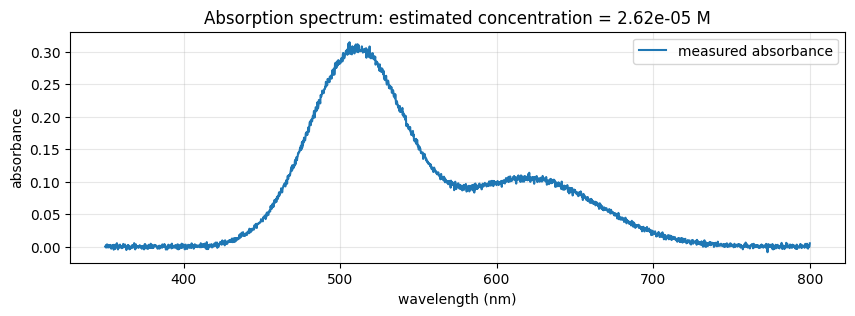

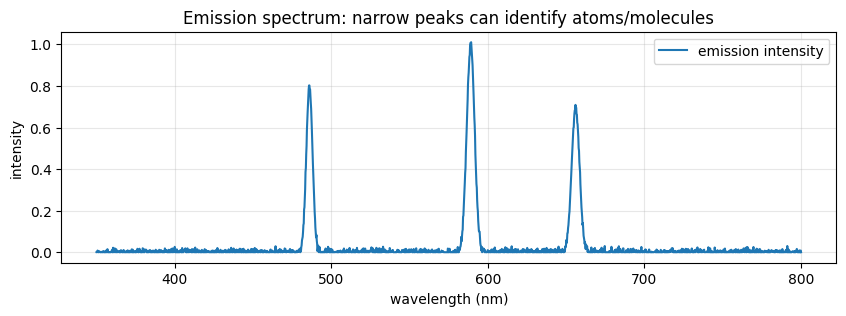

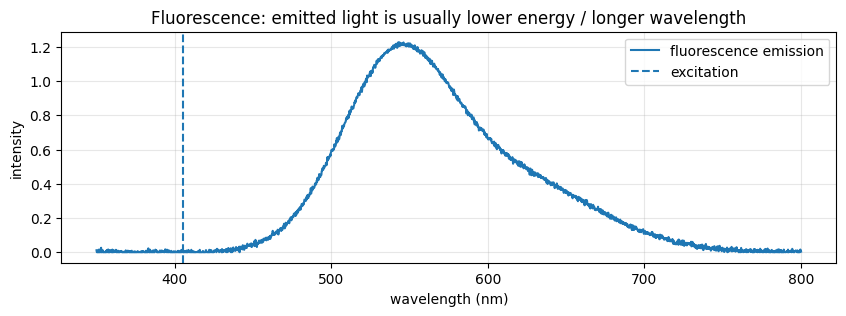

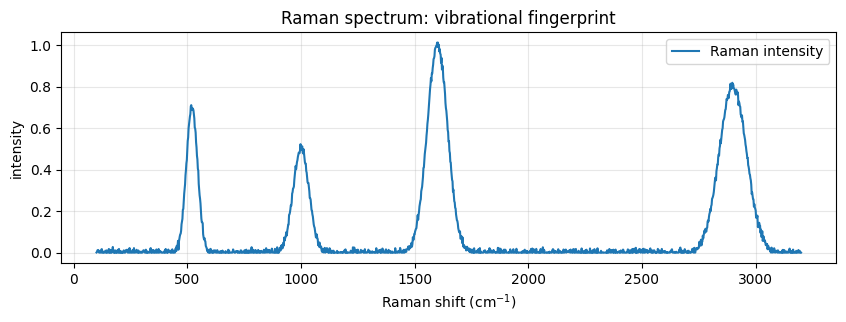

Engineered spectral features: [area, peak_position, centroid, width]
absorption   [ 34.461 506.003 547.922  63.994]
emission     [ 16.211 589.295 580.301  73.997]
fluorescence [150.014 543.147 568.862  56.673]
raman        [ 328.868 1598.624 1848.781  883.444]

Connection to computational photonics:

General chemistry spectroscopy:
    sample -> spectrum -> identify molecule / concentration

Dispersion-assisted photonic receiver:
    optical pulse -> measured intensity trace -> reconstruct spectrum or phase

AI role:
    not the measurement itself; AI learns patterns after measurement.
    Features can be spectral peaks, width, area, intensity error, phase smoothness,
    reconstruction consistency, or classifier confidence.



C:\Users\mrjel\AppData\Local\Temp\ipykernel_52892\3380283733.py:120: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(y, x)
C:\Users\mrjel\AppData\Local\Temp\ipykernel_52892\3380283733.py:122: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  centroid = np.trapz(x * y, x) / (area + 1e-12)
C:\Users\mrjel\AppData\Local\Temp\ipykernel_52892\3380283733.py:123: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  width = np.sqrt(np.trapz(((x - centroid)**2) * y, x) / (area + 1e-12))


In [1]:

# ============================================================
# General Chemistry + Photonics Spectroscopy Demo
# Absorption, Emission, Fluorescence, Raman + simple ML classifier
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(4)

# -----------------------------
# 1. Utility functions
# -----------------------------
def gaussian(x, mu, sigma, amp=1.0):
    return amp * np.exp(-0.5 * ((x - mu) / sigma)**2)

def add_noise(y, scale=0.01):
    return y + scale * np.random.randn(*y.shape)

wl = np.linspace(350, 800, 2000)  # wavelength in nm

# -----------------------------
# 2. Absorption spectroscopy
# Beer-Lambert law: A = epsilon * c * L
# -----------------------------
epsilon = 12000       # L/(mol cm), synthetic molar absorptivity
path_length = 1.0     # cm
concentration = 2.5e-5 # mol/L

absorbance_shape = gaussian(wl, 510, 30, 1.0) + 0.35 * gaussian(wl, 620, 45, 1.0)
absorbance = epsilon * concentration * path_length * absorbance_shape
transmission = 10 ** (-absorbance)
I0 = np.ones_like(wl)
I = add_noise(I0 * transmission, 0.005)
I = np.clip(I, 1e-9, None)
A_measured = -np.log10(I / I0)

# Estimate concentration from max absorbance if epsilon and path length are known
c_est = np.max(A_measured) / (epsilon * path_length)

plt.figure(figsize=(10, 3))
plt.plot(wl, A_measured, label="measured absorbance")
plt.title(f"Absorption spectrum: estimated concentration = {c_est:.2e} M")
plt.xlabel("wavelength (nm)")
plt.ylabel("absorbance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 3. Emission spectroscopy
# Peaks identify emitting species
# -----------------------------
emission = (
    gaussian(wl, 486, 2.0, 0.8) +
    gaussian(wl, 589, 2.5, 1.0) +
    gaussian(wl, 656, 2.5, 0.7)
)
emission = add_noise(emission, 0.01)
emission = np.clip(emission, 0, None)

plt.figure(figsize=(10, 3))
plt.plot(wl, emission, label="emission intensity")
plt.title("Emission spectrum: narrow peaks can identify atoms/molecules")
plt.xlabel("wavelength (nm)")
plt.ylabel("intensity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 4. Fluorescence spectroscopy
# Excitation at shorter wavelength; emission at longer wavelength
# -----------------------------
excitation_wavelength = 405
fluorescence = gaussian(wl, 540, 35, 1.0) + 0.45 * gaussian(wl, 610, 55, 1.0)
fluorescence[wl < excitation_wavelength + 20] = 0.0
fluorescence = add_noise(fluorescence, 0.008)
fluorescence = np.clip(fluorescence, 0, None)

plt.figure(figsize=(10, 3))
plt.plot(wl, fluorescence, label="fluorescence emission")
plt.axvline(excitation_wavelength, linestyle="--", label="excitation")
plt.title("Fluorescence: emitted light is usually lower energy / longer wavelength")
plt.xlabel("wavelength (nm)")
plt.ylabel("intensity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 5. Raman spectroscopy
# Raman shift in cm^-1 relative to laser line
# -----------------------------
raman_shift = np.linspace(100, 3200, 1600)  # cm^-1
raman = (
    gaussian(raman_shift, 520, 25, 0.7) +
    gaussian(raman_shift, 1000, 35, 0.5) +
    gaussian(raman_shift, 1600, 45, 1.0) +
    gaussian(raman_shift, 2900, 60, 0.8)
)
raman = add_noise(raman, 0.01)
raman = np.clip(raman, 0, None)

plt.figure(figsize=(10, 3))
plt.plot(raman_shift, raman, label="Raman intensity")
plt.title("Raman spectrum: vibrational fingerprint")
plt.xlabel("Raman shift (cm$^{-1}$)")
plt.ylabel("intensity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 6. Simple engineered features
# These features could feed ML later.
# -----------------------------
def spectral_features(x, y):
    y = np.clip(y, 0, None)
    area = np.trapz(y, x)
    peak_x = x[np.argmax(y)]
    centroid = np.trapz(x * y, x) / (area + 1e-12)
    width = np.sqrt(np.trapz(((x - centroid)**2) * y, x) / (area + 1e-12))
    return np.array([area, peak_x, centroid, width])

features = {
    "absorption": spectral_features(wl, A_measured),
    "emission": spectral_features(wl, emission),
    "fluorescence": spectral_features(wl, fluorescence),
    "raman": spectral_features(raman_shift, raman),
}

print("Engineered spectral features: [area, peak_position, centroid, width]")
for name, f in features.items():
    print(f"{name:12s}", np.round(f, 3))

# -----------------------------
# 7. How this connects to photonic phase retrieval
# -----------------------------
print("""
Connection to computational photonics:

General chemistry spectroscopy:
    sample -> spectrum -> identify molecule / concentration

Dispersion-assisted photonic receiver:
    optical pulse -> measured intensity trace -> reconstruct spectrum or phase

AI role:
    not the measurement itself; AI learns patterns after measurement.
    Features can be spectral peaks, width, area, intensity error, phase smoothness,
    reconstruction consistency, or classifier confidence.
""")
